In [ ]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
s1="/content/drive/MyDrive/Colab Notebooks/RT/20260129 (1)/FITS (1)/20260129-165657_SPECTRUM-PROJ01-GAL_01#_01# (1).fits"
s2="/content/drive/MyDrive/Colab Notebooks/RT/20260129 (1)/FITS (1)/20260129-170119_SPECTRUM-PROJ01-GAL_02#_01# (1).fits"
s3="/content/drive/MyDrive/Colab Notebooks/RT/20260129 (1)/FITS (1)/20260129-170524_SPECTRUM-PROJ01-GAL_03#_01# (1).fits"
s4="/content/drive/MyDrive/Colab Notebooks/RT/20260129 (1)/FITS (1)/20260129-170944_SPECTRUM-PROJ01-GAL_04#_01# (1).fits"


In [ ]:
files = [s1,s2,s3,s4]

file1: l=150.004°, b=0.007°
file2: l=140.011°, b=0.007°
file3: l=130.016°, b=0.004°
file4: l=130.017°, b=-19.998°


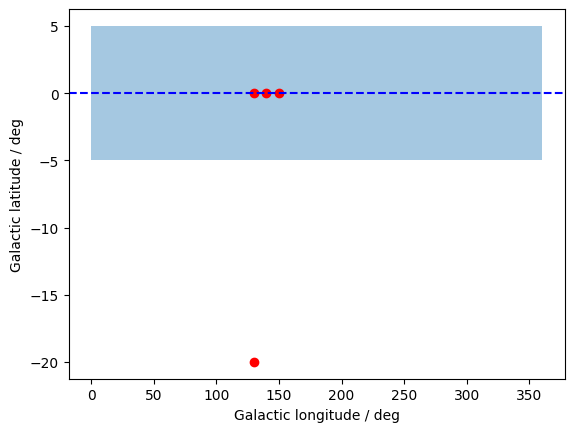

In [ ]:

from astropy.coordinates import SkyCoord
import astropy.units as u

RA_set = [
    (4 + 4/60. + 31.1/3600),
    (3 + 7/60. + 21.4/3600),
    (1 + 52/60. + 25.4/3600),
    (1 + 27/60. + 32.8/3600),

]

DEC_set = [
    52 + 25/60. + 21.0/3600,
    58 + 17/60. + 54.1/3600,
    62 + 2/60. + 2.0/3600,
    42 + 22/60. + 34.3/3600,

]

l = []
b = []



for i in range(4):
    c_icrs = SkyCoord(ra=RA_set[i]*u.hourangle, dec=DEC_set[i]*u.degree, frame='icrs')
    l.append(c_icrs.galactic.l.degree)
    b.append(c_icrs.galactic.b.degree)
    plt.plot(c_icrs.galactic.l.degree, c_icrs.galactic.b.degree, "ro")
    print(f"file{i+1}: l={c_icrs.galactic.l.degree:.3f}°, b={c_icrs.galactic.b.degree:.3f}°")

plt.xlabel("Galactic longitude / deg")
plt.ylabel("Galactic latitude / deg")

plt.axhline(y=0, color='b', linestyle='--',label='Galactic plane (b=0°)')
plt.fill_between([0, 360], -5, 5, alpha=0.4,label='Milky Way band (|b| < 5°)')# Milky Way band (|b| < 5°)
plt.show()

In [ ]:
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation, Galactic

UCLO = EarthLocation.from_geodetic(lon=-0.25*u.deg, lat=52.0*u.deg, height=100*u.m)

# Define standard solar motion parameters for LSRK correction
# Solar apex coordinates (standard value)
apex = SkyCoord(l=57.0*u.deg, b=22.0*u.deg, frame=Galactic).icrs
solar_motion_speed = 20.0 * u.km/u.s # Standard solar motion speed

for i in range(4):
    sc = SkyCoord(ra=RA_set[i]*u.hourangle, dec=DEC_set[i]*u.deg)
    obs_time = Time('2026-1-29')

    #  vEarth · n̂ (heliocentric correction)
    helio_corr = sc.radial_velocity_correction('heliocentric', obstime=obs_time, location=UCLO)

    # Calculate the solar motion component (v_sun · n̂)
    ra_rad = sc.ra.to(u.rad).value
    dec_rad = sc.dec.to(u.rad).value
    apex_ra_rad = apex.ra.to(u.rad).value
    apex_dec_rad = apex.dec.to(u.rad).value

    cos_angle = (np.sin(dec_rad) * np.sin(apex_dec_rad) + np.cos(dec_rad) * np.cos(apex_dec_rad) * np.cos(ra_rad - apex_ra_rad))    # Cosine of the angle between the source and the solar apex
    v_sun_proj = solar_motion_speed * cos_angle


    # Total LSRK correction is heliocentric correction + solar motion component
    total_corr  = helio_corr + v_sun_proj
    print(f"file{i+1}:")
    print(f" helio corr = {helio_corr.to(u.km/u.s).value:.3f} km/s, solar corr = {v_sun_proj.to(u.km/u.s).value:.3f} km/s, total vcorr (Vcorr) = {total_corr.to(u.km/u.s).value:.3f} km/s")

file1:
 helio corr = -22.237 km/s, solar corr = -0.971 km/s, total vcorr (Vcorr) = -23.208 km/s
file2:
 helio corr = -21.609 km/s, solar corr = 2.257 km/s, total vcorr (Vcorr) = -19.352 km/s
file3:
 helio corr = -20.327 km/s, solar corr = 5.417 km/s, total vcorr (Vcorr) = -14.909 km/s
file4:
 helio corr = -26.221 km/s, solar corr = 2.527 km/s, total vcorr (Vcorr) = -23.694 km/s


In [ ]:
def read_spec(f, status_filter=('on')):
    h = fits.open(f, ignore_missing_end=True)
    d = h[1].data
    hdr = h[1].header
    base = hdr["BASEFREQ"]
    bw   = hdr["BANDWID"]
    n    = 1024
    freq = (base + (np.arange(n) + 0.5) * (bw / n)) / 1e9

    status=np.array([s.strip().lower() for s in d.field('STATUS')])#remove cal STATUS can remove off
    mask=np.isin(status, status_filter)

    left=d.field(7)[mask]
    right=d.field(8)[mask]

    l_mean=np.mean(left, axis=0)
    r_mean=np.mean(right, axis=0)
    l_err=np.std(left, axis=0, ddof=1)/np.sqrt(left.shape[0])
    r_err=np.std(right, axis=0, ddof=1)/np.sqrt(right.shape[0])
    h.close()

    return freq, l_mean, r_mean, l_err, r_err

freq_off, off_l, off_r, off_l_err, off_r_err=read_spec(s4, status_filter=('on'))

DIAMETER =                    3  / TELESCOPE diameter                            [astropy.io.fits.card]
DIAMETER =                    3  / TELESCOPE diameter                           


/tmp/ipykernel_38527/2572548461.py:5: RuntimeWarning: invalid value encountered in divide
  sub_l=(on_l-off_l)/off_l
/tmp/ipykernel_38527/2572548461.py:6: RuntimeWarning: invalid value encountered in divide
  sub_r=(on_r-off_r)/off_r
/tmp/ipykernel_38527/2572548461.py:8: RuntimeWarning: invalid value encountered in divide
  sub_l_err=np.sqrt((on_l_err/off_l)**2+(on_l*off_l_err/off_l**2)**2)
/tmp/ipykernel_38527/2572548461.py:9: RuntimeWarning: invalid value encountered in divide
  sub_r_err=np.sqrt((on_r_err/off_r)**2+(on_r*off_r_err/off_r**2)**2)


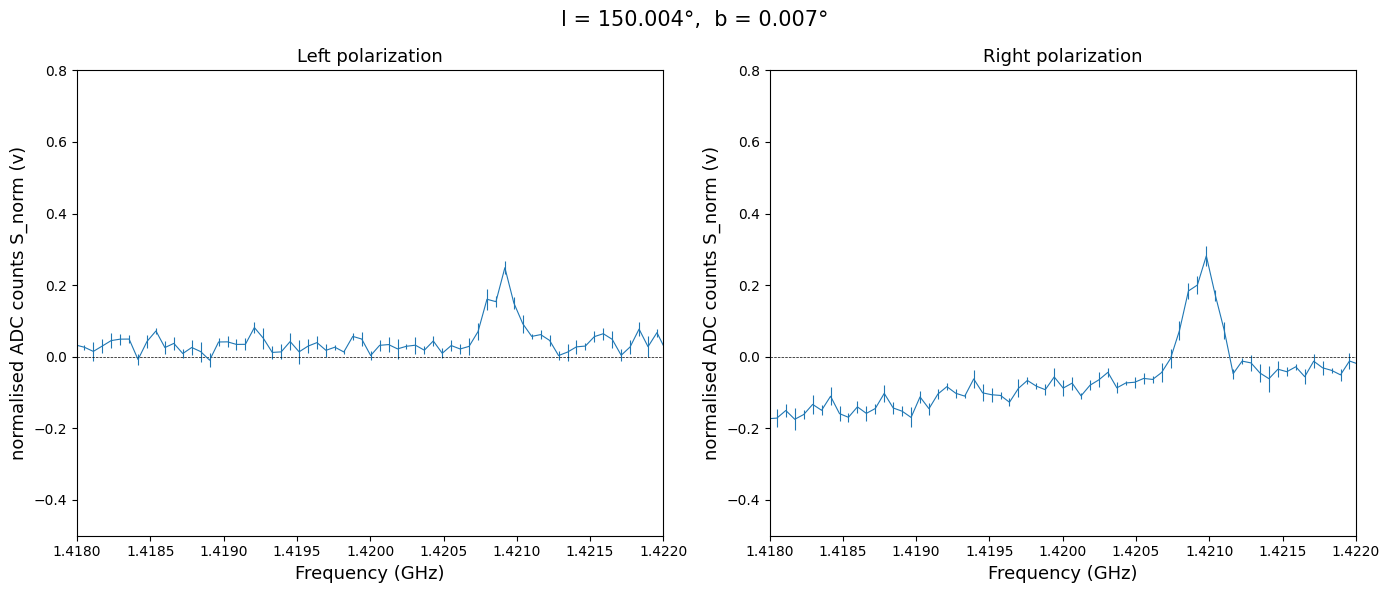

nan


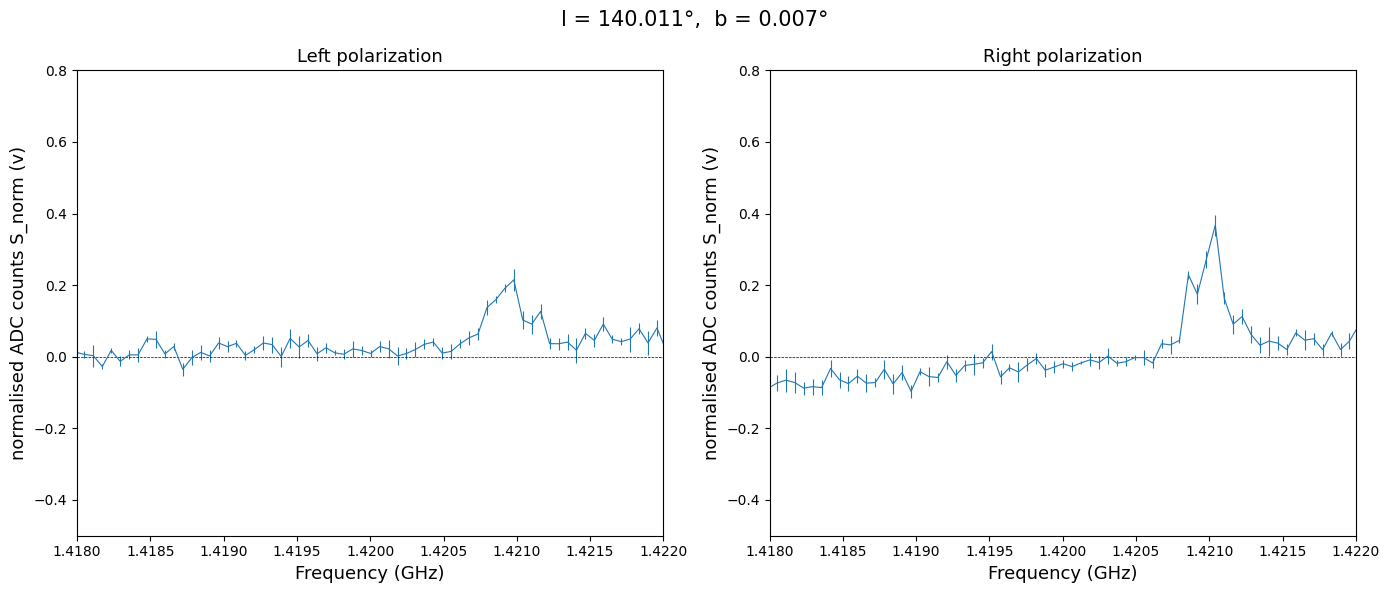

nan


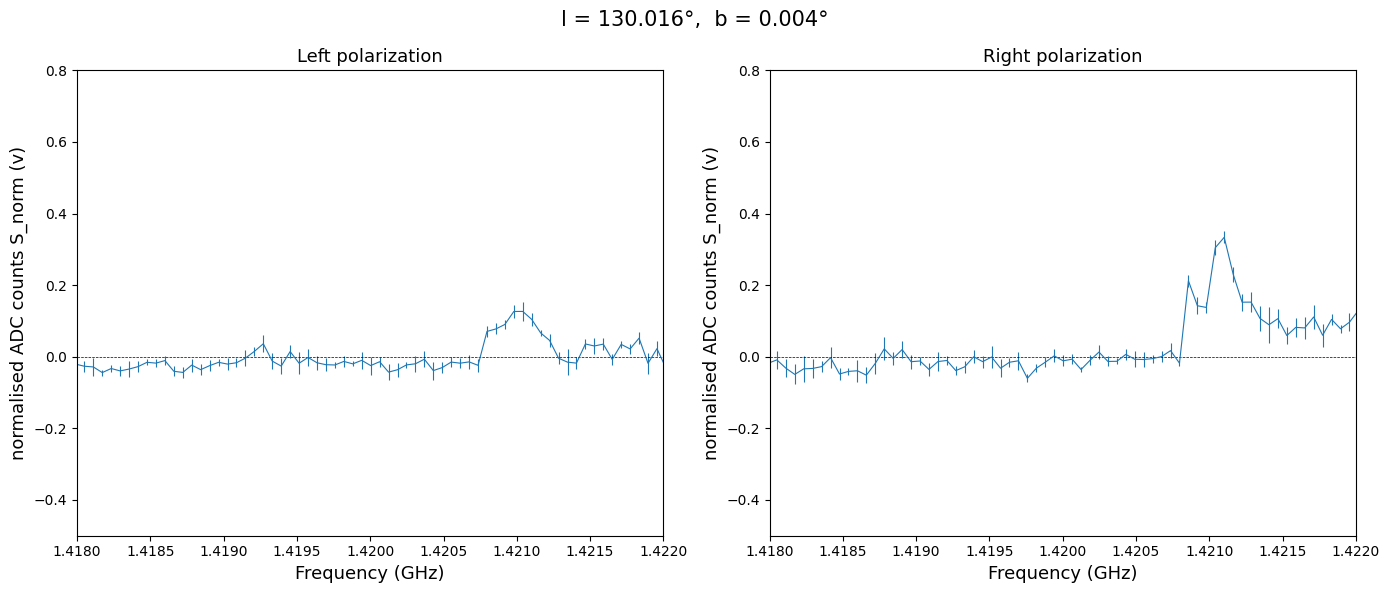

nan


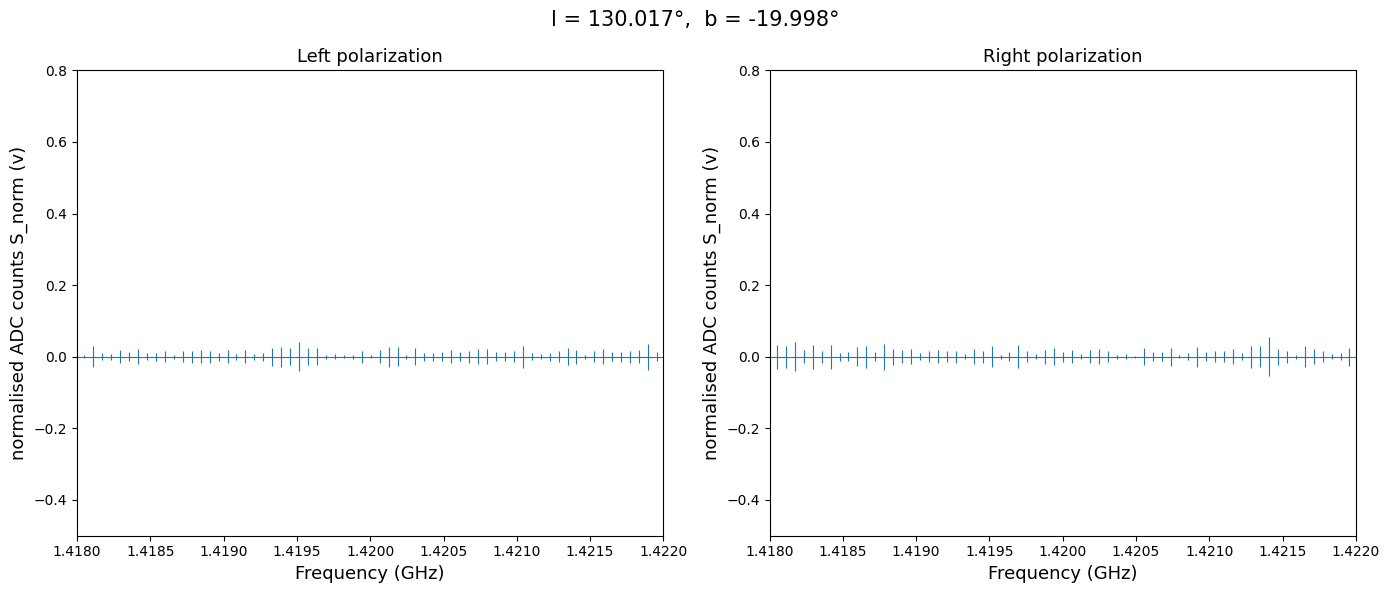

nan


In [ ]:
for i, f in enumerate(files[:4]):
    freq, on_l, on_r, on_l_err, on_r_err=read_spec(f, status_filter=('on'))

    #normalised the signal after subtraction
    sub_l=(on_l-off_l)/off_l
    sub_r=(on_r-off_r)/off_r

    sub_l_err=np.sqrt((on_l_err/off_l)**2+(on_l*off_l_err/off_l**2)**2)
    sub_r_err=np.sqrt((on_r_err/off_r)**2+(on_r*off_r_err/off_r**2)**2)

    plt.figure(figsize=(14, 6))
    plt.suptitle(f"l = {l[i]:.3f}°,  b = {b[i]:.3f}°", fontsize=15)

    for j,(sig,error,label) in enumerate(zip([sub_l,sub_r],[sub_l_err,sub_r_err],["Left polarization","Right polarization"])):
        plt.subplot(1,2,j+1)
        plt.errorbar(freq, sig, yerr=error, lw=0.8)
        plt.axhline(0, color='k', lw=0.5, ls='--')
        plt.xlabel("Frequency (GHz)", fontsize=13)
        plt.ylabel("normalised ADC counts S_norm (v)", fontsize=13)
        plt.title(label, fontsize=13)
        plt.xlim(1.418,1.422)
        plt.ylim(-0.5,0.8)
    plt.tight_layout()

    plt.show()

    print(f"{np.max(sub_l)}")


In [ ]:
def sub_spec(on, on_err, off, off_err):
    sub=(on-off)/off
    sub_err=np.sqrt((on_err/off)**2+(on*off_err/off**2)**2)
    return sub, sub_err

DIAMETER =                    3  / TELESCOPE diameter                            [astropy.io.fits.card]
DIAMETER =                    3  / TELESCOPE diameter                           
/tmp/ipykernel_38527/1676434105.py:2: RuntimeWarning: invalid value encountered in divide
  sub=(on-off)/off
/tmp/ipykernel_38527/1676434105.py:3: RuntimeWarning: invalid value encountered in divide
  sub_err=np.sqrt((on_err/off)**2+(on*off_err/off**2)**2)


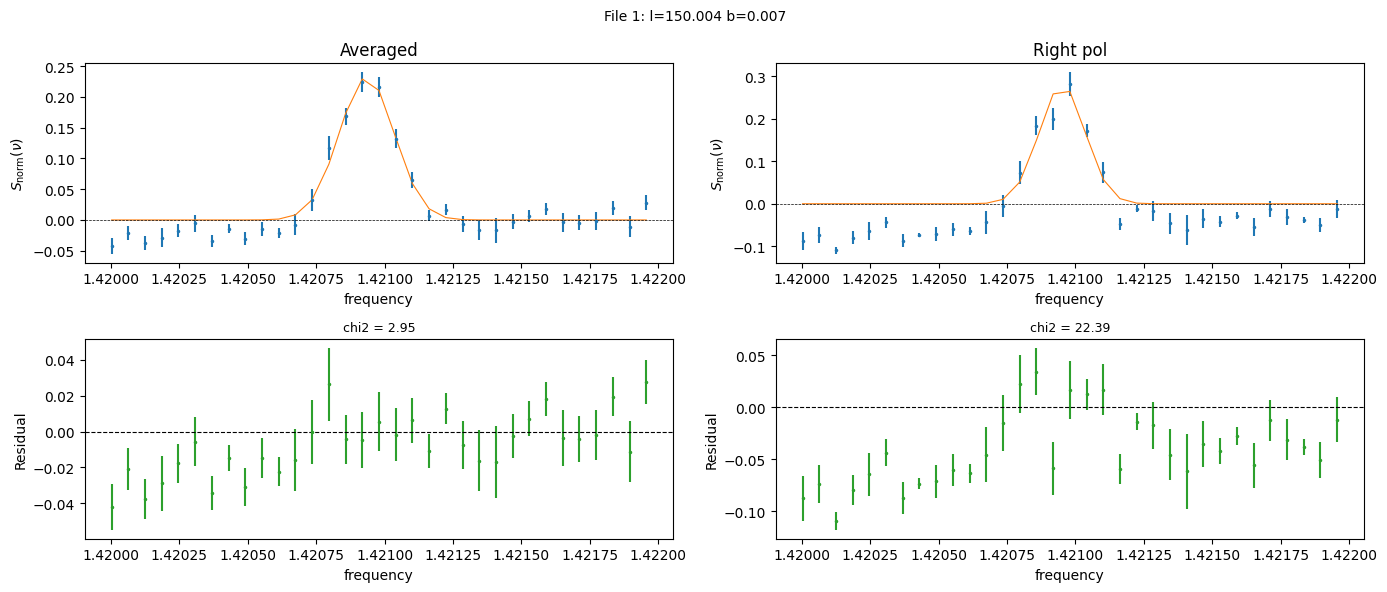

Avg_A=0.2323±0.0110 | mu=1.42093505±0.00000552 GHz，chi2=2.95
R_A=0.2796±0.0203 | mu=1.42095181±0.00000571 GHz， chi2 =22.39


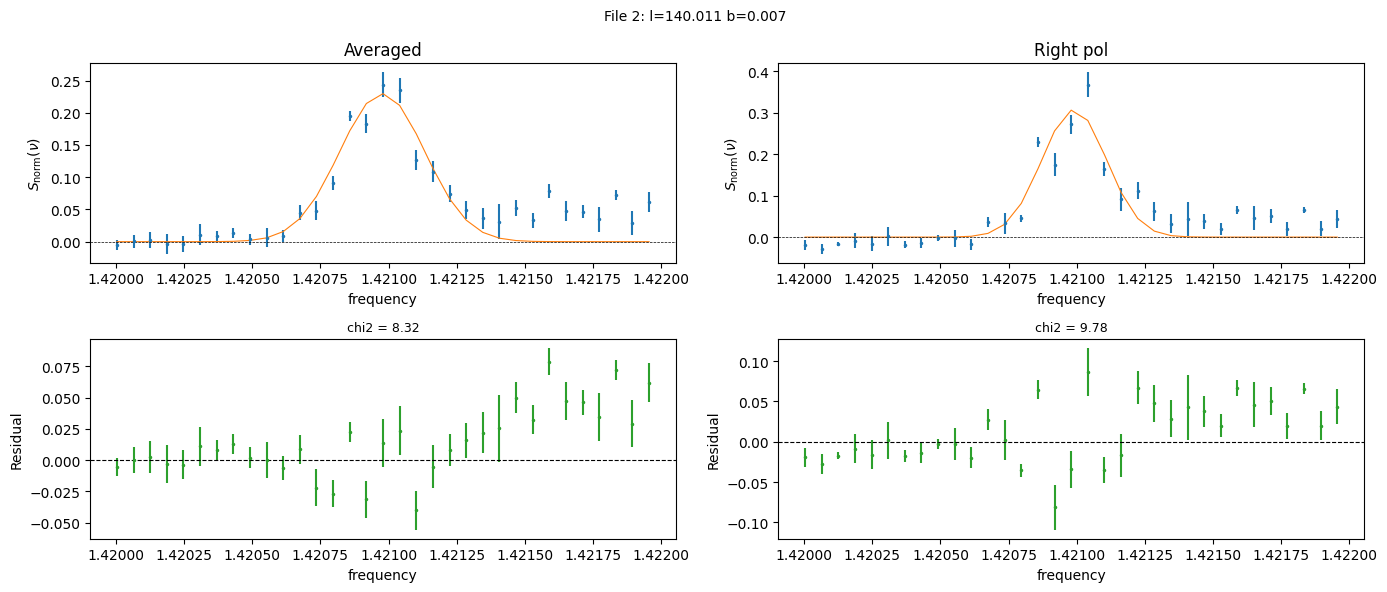

Avg_A=0.2297±0.0089 | mu=1.42097704±0.00000593 GHz，chi2=8.32
R_A=0.3074±0.0154 | mu=1.42099067±0.00000513 GHz， chi2 =9.78


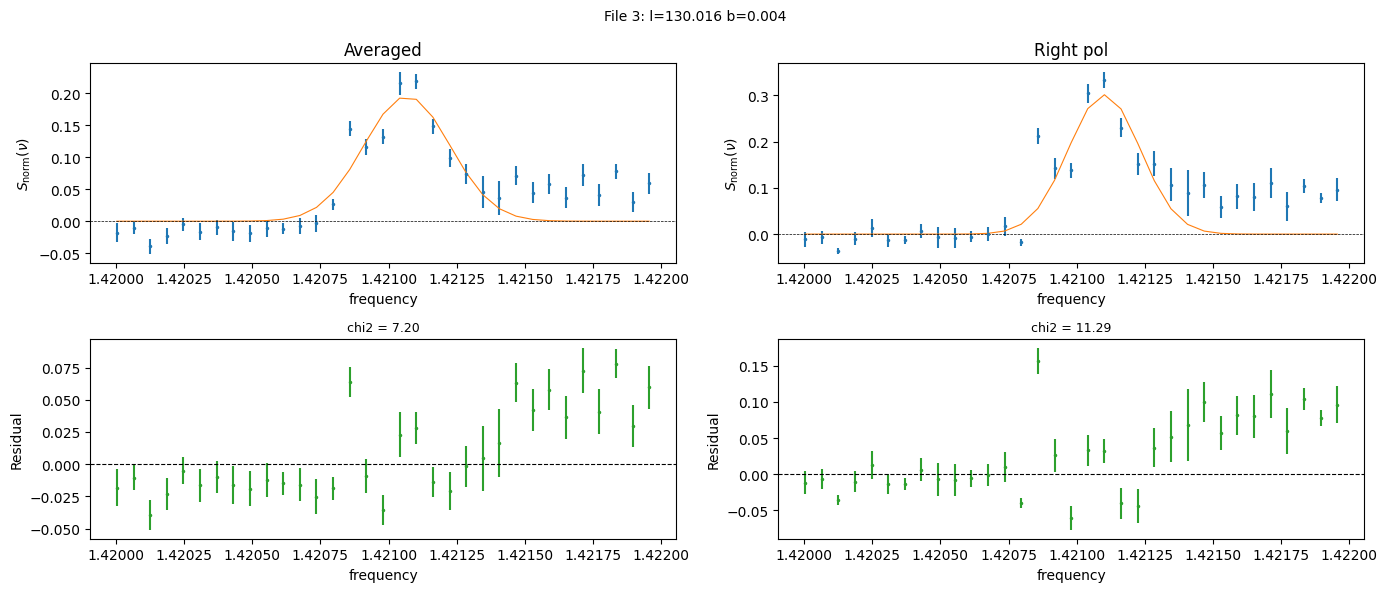

Avg_A=0.1953±0.0076 | mu=1.42106740±0.00000732 GHz，chi2=7.20
R_A=0.3016±0.0114 | mu=1.42110143±0.00000704 GHz， chi2 =11.29


In [ ]:
from scipy.optimize import curve_fit
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)

for i, f in enumerate(files[:3]):
    freq, on_l, on_r, on_l_err, on_r_err=read_spec(f)
    sub_l, sub_l_err=sub_spec(on_l, on_l_err, off_l, off_l_err)
    sub_r, sub_r_err=sub_spec(on_r, on_r_err, off_r, off_r_err)

    #average the two polarizations
    sub_avg=0.5*(sub_l+sub_r)
    sub_avg_err=0.5*np.sqrt(sub_l_err**2+sub_r_err**2)

    #around H I line
    fit_mask=(freq>1.42)&(freq<1.422)
    x_fit=freq[fit_mask]
    y_fit=sub_avg[fit_mask]
    y_err=sub_avg_err[fit_mask]
    y_fit1=sub_r[fit_mask]
    y_err1=sub_r_err[fit_mask]

    p0=[np.nanmax(y_fit),x_fit[np.nanargmax(y_fit)],0.0005]
    p01=[np.nanmax(y_fit1),x_fit[np.nanargmax(y_fit1)],0.0005]
    popt,pcov=curve_fit(gaussian,x_fit,y_fit,p0=p0,sigma=y_err,absolute_sigma=True)
    popt1,pcov1=curve_fit(gaussian,x_fit,y_fit1,p0=p01,sigma=y_err1,absolute_sigma=True)

    A_fit,mu_fit,sigma_fit=popt
    A_err,mu_err,sigma_err=np.sqrt(np.diag(pcov))
    A_fit1,mu_fit1,sigma_fit1=popt1
    A_err1,mu_err1,sigma_err1=np.sqrt(np.diag(pcov1))

    res=y_fit-gaussian(x_fit,*popt)
    res1=y_fit1-gaussian(x_fit,*popt1)

    chi2=np.sum((res/y_err)**2)/(len(y_fit)-3)
    chi2_1=np.sum((res1/y_err1)**2)/(len(y_fit1)-3)

    fig,axes=plt.subplots(2,2,figsize=(14,6))
    fig.suptitle(f"File {i+1}: l={l[i]:.3f} b={b[i]:.3f}",fontsize=10)
    for col,(sig,err,fit,r,label) in enumerate(zip([y_fit,y_fit1],[y_err,y_err1],[gaussian(x_fit,*popt),gaussian(x_fit,*popt1)],[res,res1],["Averaged","Right pol"])):

        axes[0,col].errorbar(x_fit,sig,yerr=err,fmt='.',ms=3)
        axes[0,col].plot(x_fit,fit,lw=0.8,label='Gaussian fit')
        axes[0,col].axhline(0,color='k',lw=0.5,ls='--')
        axes[0,col].set_xlabel("frequency")
        axes[0,col].set_ylabel(r"$S_{\rm norm}(\nu)$")
        axes[0,col].set_title(label)

        c=chi2 if col==0 else chi2_1
        axes[1,col].errorbar(x_fit,r,yerr=err,fmt='.',ms=3,color='C2')
        axes[1,col].axhline(0,color='k',lw=0.8,ls='--')
        axes[1,col].set_xlabel("frequency")
        axes[1,col].set_ylabel("Residual")
        axes[1,col].set_title(f"chi2 = {c:.2f}",fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f"Avg_A={A_fit:.4f}±{A_err:.4f} | mu={mu_fit:.8f}±{mu_err:.8f} GHz，chi2={chi2:.2f}")
    print(f"R_A={A_fit1:.4f}±{A_err1:.4f} | mu={mu_fit1:.8f}±{mu_err1:.8f} GHz， chi2 ={chi2_1:.2f}")

/tmp/ipykernel_38527/1676434105.py:2: RuntimeWarning: invalid value encountered in divide
  sub=(on-off)/off
/tmp/ipykernel_38527/1676434105.py:3: RuntimeWarning: invalid value encountered in divide
  sub_err=np.sqrt((on_err/off)**2+(on*off_err/off**2)**2)


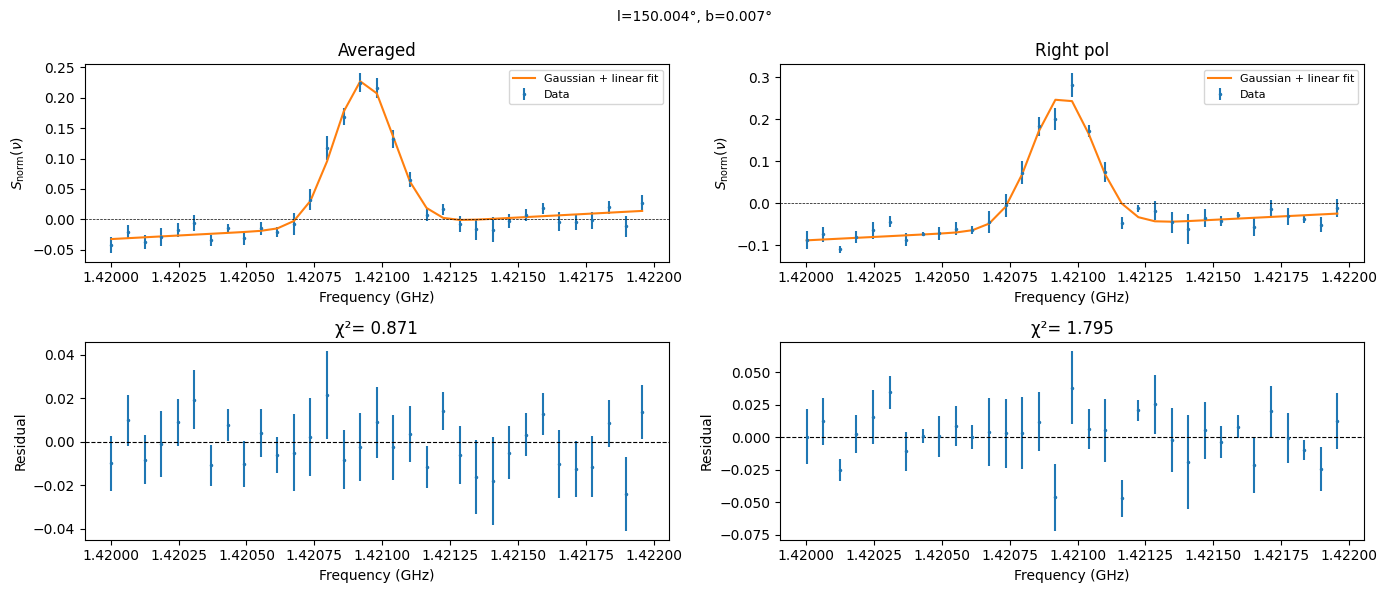

Avg_mu=1.42093145±0.00000562 GHz,A=0.2392±0.0106 chi2=0.871
Right_mu=1.42094560±0.00000608 GHz,A=0.3135±0.0157 chi2=1.795


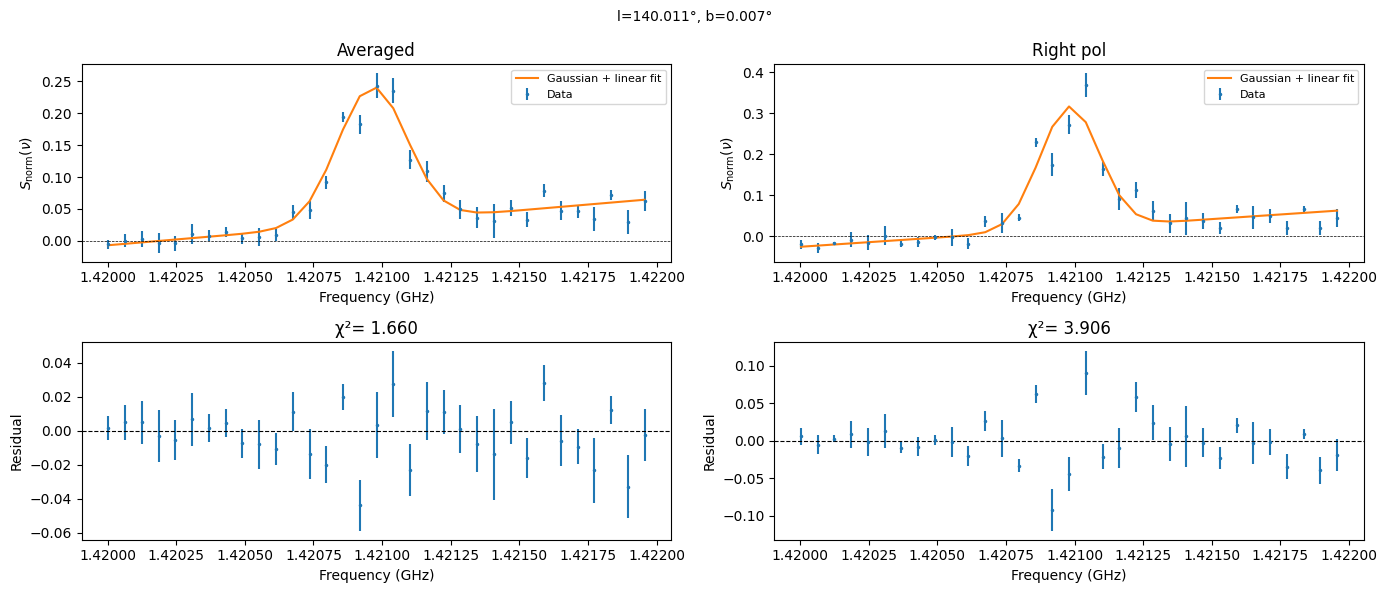

Avg_mu=1.42096350±0.00000590 GHz,A=0.2130±0.0103 chi2=1.660
Right_mu=1.42098192±0.00000503 GHz,A=0.2978±0.0164 chi2=3.906


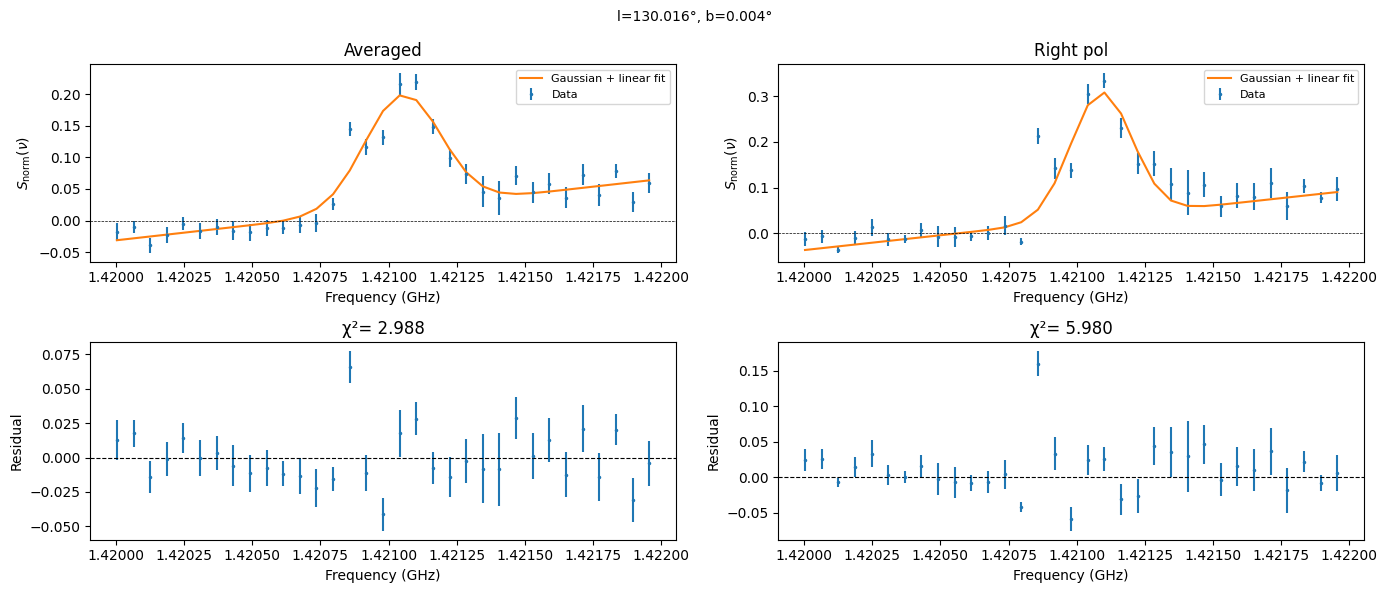

Avg_mu=1.42105199±0.00000719 GHz,A=0.1793±0.0085 chi2=2.988
Right_mu=1.42109031±0.00000682 GHz,A=0.2744±0.0126 chi2=5.980


In [ ]:
def gaussian_linear(x, A, mu, sigma, m, b):
    return A*np.exp(-0.5*((x-mu)/sigma)**2)+m*x+b

for i, f in enumerate(files[:3]):
    freq, on_l, on_r, on_l_err, on_r_err=read_spec(f)
    sub_l, sub_l_err=sub_spec(on_l, on_l_err, off_l, off_l_err)
    sub_r, sub_r_err=sub_spec(on_r, on_r_err, off_r, off_r_err)

    sub_avg=0.5*(sub_l+sub_r)
    sub_avg_err=0.5*np.sqrt(sub_l_err**2+sub_r_err**2)

    fit_mask=(freq>1.420)&(freq<1.422)
    x_fit=freq[fit_mask]
    y_fit=sub_avg[fit_mask]
    y_err=sub_avg_err[fit_mask]
    y_fit1=sub_r[fit_mask]
    y_err1=sub_r_err[fit_mask]

    p0=[np.nanmax(y_fit)-np.nanmedian(y_fit), x_fit[np.nanargmax(y_fit)], 5.5e-5, 0, np.nanmedian(y_fit)]
    p01=[np.nanmax(y_fit1), x_fit[np.nanargmax(y_fit1)], 5.5e-5, 1, np.nanmedian(y_fit1)]
    popt,pcov=curve_fit(gaussian_linear,x_fit,y_fit,p0=p0,sigma=y_err,absolute_sigma=True,maxfev=20000)
    popt1,pcov1=curve_fit(gaussian_linear,x_fit,y_fit1,p0=p0,sigma=y_err1,absolute_sigma=True,maxfev=20000)

    A_fit,mu_fit,sigma_fit,m_fit,b_fit=popt
    A_err,mu_err,sigma_err,m_err,b_err=np.sqrt(np.diag(pcov))
    A_fit1,mu_fit1,sigma_fit1,m_fit1,b_fit1=popt1
    A_err1,mu_err1,sigma_err1,m_err1,b_err1=np.sqrt(np.diag(pcov1))

    res=y_fit-gaussian_linear(x_fit,*popt)
    res1=y_fit1-gaussian_linear(x_fit,*popt1)
    chi2=np.sum((res/y_err)**2)/(len(y_fit)-5)#change in rof
    chi2_1=np.sum((res1/y_err1)**2)/(len(y_fit1)-5)

    fig,axes=plt.subplots(2,2,figsize=(14,6))
    fig.suptitle(f"l={l[i]:.3f}°, b={b[i]:.3f}°",fontsize=10)
    for col,(sig,err,r,label) in enumerate(zip([y_fit,y_fit1],[y_err,y_err1],[res,res1],["Averaged","Right pol"])):

        po=popt if col==0 else popt1
        c=chi2 if col==0 else chi2_1
        axes[0,col].errorbar(x_fit,sig,yerr=err,fmt='.',ms=3,label='Data')
        axes[0,col].plot(x_fit,gaussian_linear(x_fit,*po),lw=1.5,label='Gaussian + linear fit')
        axes[0,col].axhline(0,color='k',lw=0.5,ls='--')
        axes[0,col].set_xlabel("Frequency (GHz)")
        axes[0,col].set_ylabel(r"$S_{\rm norm}(\nu)$")
        axes[0,col].set_title(label)
        axes[0,col].legend(fontsize=8)


        axes[1,col].errorbar(x_fit,r,yerr=err,fmt='.',ms=3)
        axes[1,col].axhline(0,color='k',lw=0.8,ls='--')
        axes[1,col].set_xlabel("Frequency (GHz)")
        axes[1,col].set_ylabel("Residual")
        axes[1,col].set_title(f"χ²= {c:.3f}")

    plt.tight_layout()
    plt.show()
    print(f"Avg_mu={mu_fit:.8f}±{mu_err:.8f} GHz,A={A_fit:.4f}±{A_err:.4f} chi2={chi2:.3f}")
    print(f"Right_mu={mu_fit1:.8f}±{mu_err1:.8f} GHz,A={A_fit1:.4f}±{A_err1:.4f} chi2={chi2_1:.3f}")

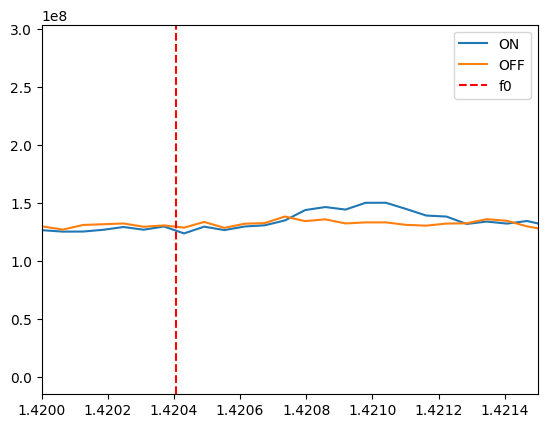

11860669.666666687


In [ ]:
fig, ax = plt.subplots()
ax.plot(freq, on_l, label='ON')
ax.plot(freq, off_l, label='OFF')
ax.axvline(1420.406e6/1e9, color='r', linestyle='--', label='f0')
ax.set_xlim(1.42, 1.4215)
ax.legend()
plt.show()

mask=(freq>1.420)&(freq<1.422)
max=np.max(on_l[mask])
max1=np.max(off_l[mask])
sub=max-max1
print(sub)

It can be seen that there's noly one peak when l=150
The side peak is more obvious when l=130 than l=140 which satisfied the theoretical representaation.

DONNOT USE AVERAGE！！！
The signal in left-hand polarization is weak and will lose the side peak.

/tmp/ipykernel_38527/1676434105.py:2: RuntimeWarning: invalid value encountered in divide
  sub=(on-off)/off
/tmp/ipykernel_38527/1676434105.py:3: RuntimeWarning: invalid value encountered in divide
  sub_err=np.sqrt((on_err/off)**2+(on*off_err/off**2)**2)


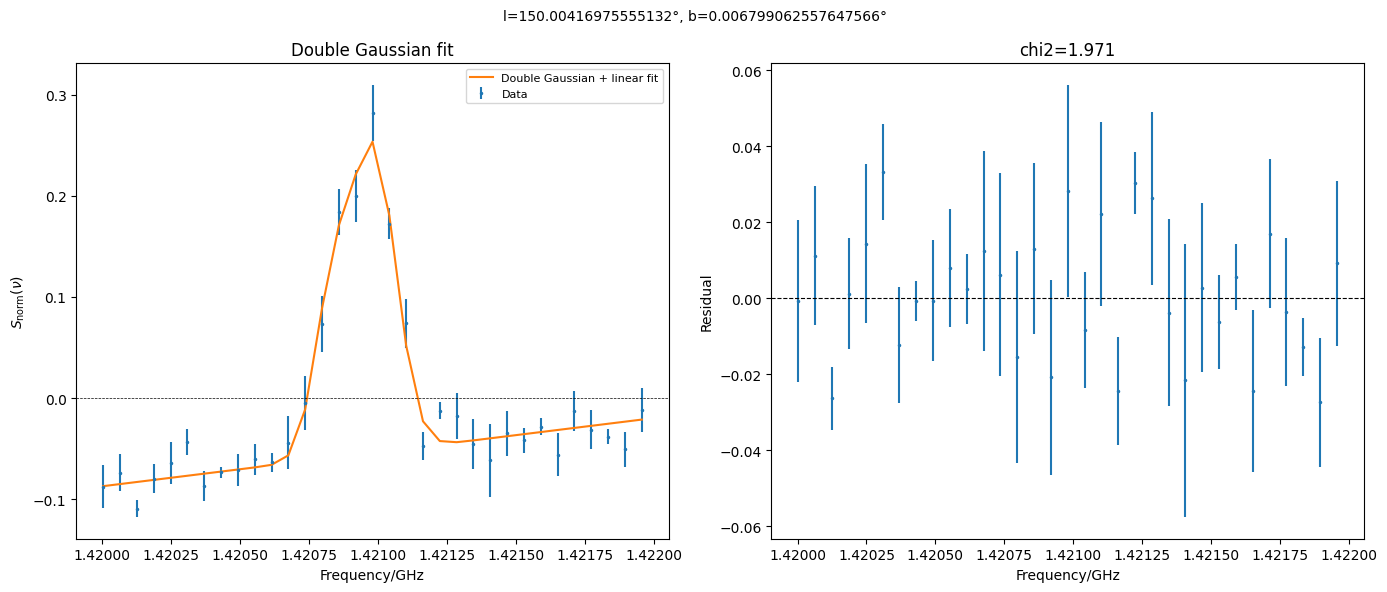

l=150.00416975555132°
Peak1: mu=1420.9852±0.0320 MHz
 v_LSR=-145.5±6.8 km/s
Peak2: mu=1420.8350±0.0465 MHz
 v_LSR=-113.8±9.8 km/s
chi2=1.971


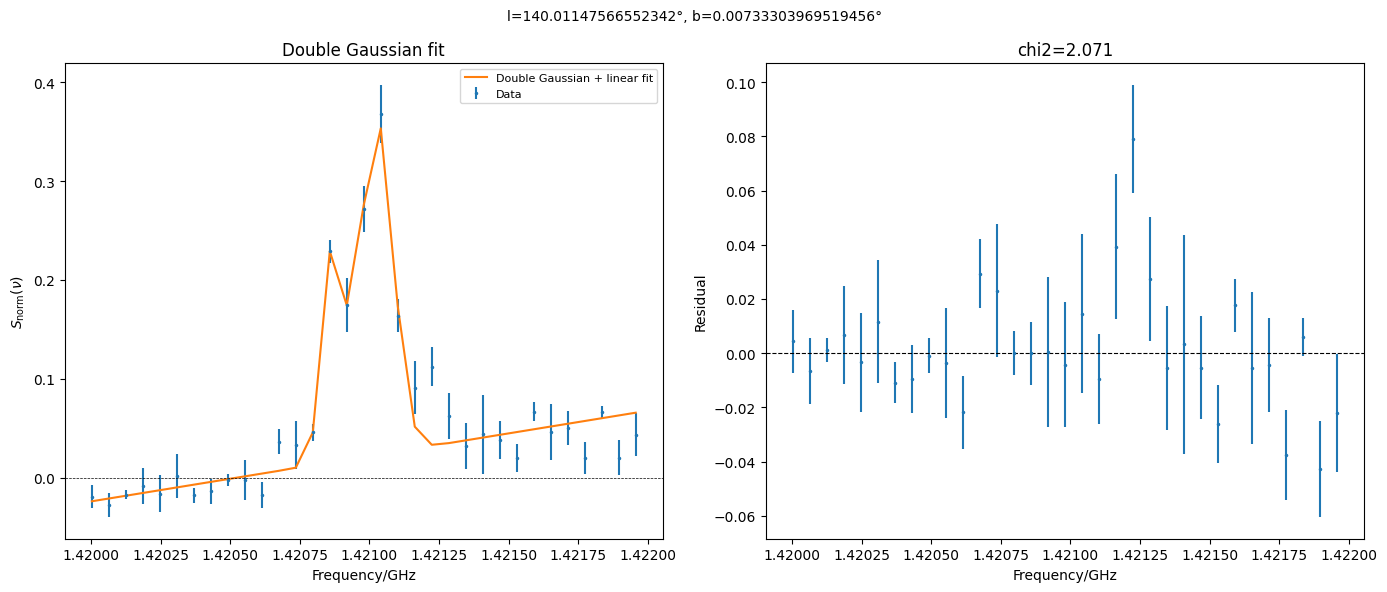

l=140.01147566552342°
Peak1: mu=1421.0254±0.0052 MHz
 v_LSR=-150.2±1.1 km/s
Peak2: mu=1420.8691±0.0070 MHz
 v_LSR=-117.2±1.5 km/s
chi2=2.071


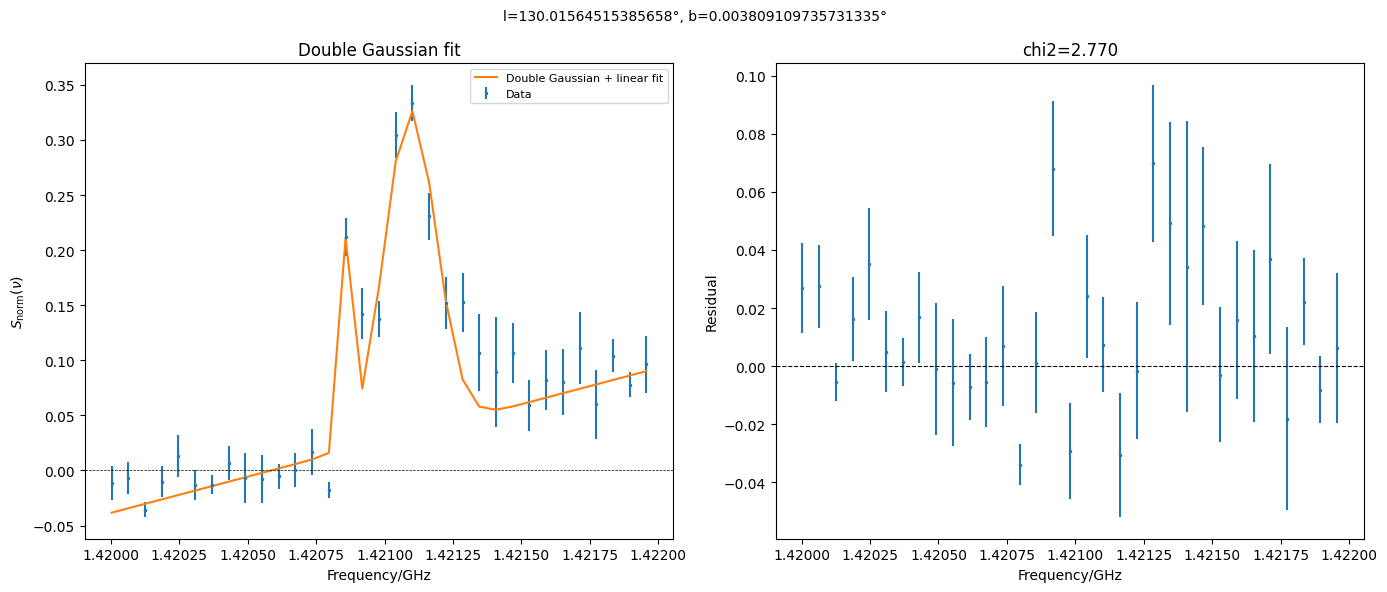

l=130.01564515385658°
Peak1: mu=1421.0935±0.0058 MHz
 v_LSR=-160.1±1.2 km/s
Peak2: mu=1420.8620±0.1692 MHz
 v_LSR=-111.2±35.7 km/s
chi2=2.770


In [ ]:
f0=1420.406e6/1e9
def double_gaussian_linear(x, A1, mu1, s1, A2, mu2, s2, m, b):
    g1=A1*np.exp(-0.5*((x-mu1)/s1)**2)
    g2=A2*np.exp(-0.5*((x-mu2)/s2)**2)
    return g1+g2+m*x+b

vcorr=[-23.208,-19.352,-14.909]  # km/s
sigma_max_dict={0:8e-5, 1:8e-5, 2:6e-4}
sigma_min=1.5e-5

for i, f in enumerate(files[:3]):
    freq, on_l, on_r, on_l_err, on_r_err=read_spec(f)
    sub_l, sub_l_err=sub_spec(on_l, on_l_err, off_l, off_l_err)
    sub_r, sub_r_err=sub_spec(on_r, on_r_err, off_r, off_r_err)

    fit_mask=(freq>1.420)&(freq<1.422)
    x_fit=freq[fit_mask]
    y_fit=sub_r[fit_mask]
    y_err=sub_r_err[fit_mask]
    valid=np.isfinite(y_fit)&np.isfinite(y_err)
    x_fit,y_fit,y_err=x_fit[valid],y_fit[valid],y_err[valid]

    sigma_max=sigma_max_dict[i]
    p0=[0.22,1.42100,3e-5, 0.05,1.42080,2e-5, 0.0,np.nanmedian(y_fit)]
    lo=[0,1.42085,sigma_min, 0,1.42065,sigma_min, -np.inf,-np.inf]
    hi=[np.inf,1.42115,sigma_max, np.inf,1.42095,sigma_max, np.inf,np.inf]

    popt,pcov=curve_fit(double_gaussian_linear,x_fit,y_fit,p0=p0,sigma=y_err,absolute_sigma=True,bounds=(lo,hi),maxfev=50000)
    perr=np.sqrt(np.diag(pcov))

    A1,mu1,s1,A2,mu2,s2,m_fit,b_fit=popt
    A1e,mu1e,s1e,A2e,mu2e,s2e,me,be=perr

    v1_raw=(f0-mu1)/f0*3e5
    v2_raw=(f0-mu2)/f0*3e5
    v1_lsr=v1_raw+vcorr[i]
    v2_lsr=v2_raw+vcorr[i]

    v1_err=mu1e/f0*3e5
    v2_err=mu2e/f0*3e5

    res=y_fit-double_gaussian_linear(x_fit,*popt)
    chi2=np.sum((res/y_err)**2)/(len(y_fit)-8)

    plt.figure(figsize=(14,6))
    plt.suptitle(f"l={l[i]}°, b={b[i]}°",fontsize=10)

    plt.subplot(1,2,1)
    plt.errorbar(x_fit,y_fit,yerr=y_err,fmt='.',ms=3,label='Data')
    plt.plot(x_fit,double_gaussian_linear(x_fit,*popt),lw=1.5,label='Double Gaussian + linear fit')
    plt.axhline(0,color='k',lw=0.5,ls='--')
    plt.xlabel("Frequency/GHz")
    plt.ylabel(r"$S_{\rm norm}(\nu)$")
    plt.title("Double Gaussian fit")
    plt.legend(fontsize=8)

    plt.subplot(1,2,2)
    plt.errorbar(x_fit,res,yerr=y_err,fmt='.',ms=3)
    plt.axhline(0,color='k',lw=0.8,ls='--')
    plt.xlabel("Frequency/GHz")
    plt.ylabel("Residual")
    plt.title(f"chi2={chi2:.3f}")
    plt.tight_layout()
    plt.show()

    print(f"l={l[i]}°")
    print(f"Peak1: mu={mu1*1e3:.4f}±{mu1e*1e3:.4f} MHz\n v_LSR={v1_lsr:.1f}±{v1_err:.1f} km/s")
    print(f"Peak2: mu={mu2*1e3:.4f}±{mu2e*1e3:.4f} MHz\n v_LSR={v2_lsr:.1f}±{v2_err:.1f} km/s")
    print(f"chi2={chi2:.3f}")